# Cell 1：导入库、读取数据

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

factor_file = PROCESSED_DIR / "etf_factors_long.csv"

factor_data = pd.read_csv(factor_file, encoding="utf-8-sig")
factor_data["date"] = pd.to_datetime(factor_data["date"])
factor_data = factor_data.sort_values(["date", "symbol"]).reset_index(drop=True)

print("数据形状:", factor_data.shape)
print("ETF 数量:", factor_data["symbol"].nunique())
print("日期范围:", factor_data["date"].min(), "到", factor_data["date"].max())

factor_data.head()

数据形状: (25810, 32)
ETF 数量: 14
日期范围: 2018-01-02 00:00:00 到 2026-06-12 00:00:00


,date,open,high,low,close,volume,amount,amplitude,pct_change,change,...,future_return_20d,z_mom_5,z_mom_20,z_mom_60,z_vol_20,z_drawdown_20,z_amount_change_20,alpha_score,alpha_rank,n_assets_on_date
0,2018-01-02,1.650,1.676,1.646,1.665,983128,163062394.0,1.82,1.28,0.021,...,0.013213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2018-01-02,3.428,3.480,3.426,3.478,1688766,695160736.0,1.58,1.76,0.060,...,0.048304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2018-01-02,5.531,5.592,5.520,5.589,525743,349300160.0,1.31,1.38,0.076,...,-0.005368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2018-01-02,2.176,2.195,2.173,2.195,16427,1360313.0,1.01,1.11,0.024,...,-0.017312,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2018-01-02,0.844,0.849,0.842,0.849,90641,7668141.0,0.83,0.83,0.007,...,-0.036514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


# Cell 2：准备回归变量

In [2]:
# 原始因子列
raw_factor_cols = [
    "mom_20",
    "mom_60",
    "vol_20",
    "drawdown_20",
    "amount_change_20",
]

# 对应的横截面标准化因子列
z_factor_cols = [f"z_{col}" for col in raw_factor_cols]

future_return_cols = [
    "future_return_1d",
    "future_return_5d",
    "future_return_20d",
]

# 如果 z-score 列不存在，则重新计算
def zscore_cross_section(x):
    std = x.std(ddof=0)
    if std == 0 or np.isnan(std):
        return pd.Series(np.nan, index=x.index)
    return (x - x.mean()) / std

for col in raw_factor_cols:
    z_col = f"z_{col}"
    if z_col not in factor_data.columns:
        factor_data[z_col] = factor_data.groupby("date")[col].transform(zscore_cross_section)

# 检查必要列
required_cols = ["date", "symbol", "name", "alpha_score"] + z_factor_cols + future_return_cols

missing_cols = [col for col in required_cols if col not in factor_data.columns]

if missing_cols:
    raise ValueError(f"缺失必要字段: {missing_cols}")
else:
    print("所有回归必要字段均存在。")

reg_data = factor_data[required_cols].dropna().copy()

print("回归样本形状:", reg_data.shape)
print("有效日期数:", reg_data["date"].nunique())
print("ETF 数量:", reg_data["symbol"].nunique())

reg_data.head()

所有回归必要字段均存在。
回归样本形状: (24681, 12)
有效日期数: 1966
ETF 数量: 14


,date,symbol,name,alpha_score,z_mom_20,z_mom_60,z_vol_20,z_drawdown_20,z_amount_change_20,future_return_1d,future_return_5d,future_return_20d
540,2018-04-03,159915,创业板ETF,1.263204,1.190037,2.039080,1.296939,0.874509,0.560433,-0.018141,-0.024943,-0.008503
541,2018-04-03,510300,沪深300ETF,-0.897683,-1.076218,-0.823177,-0.465883,-0.923757,-0.463507,-0.003081,0.010474,-0.008318
542,2018-04-03,510500,中证500ETF,-0.282561,-0.029821,-0.385541,0.226599,0.188398,-1.087759,-0.008452,-0.002630,-0.006198
543,2018-04-03,512100,中证1000ETF,-0.045162,0.360217,-0.353759,0.235817,0.520930,-1.047682,-0.006686,-0.002388,-0.014327
544,2018-04-03,512660,军工ETF,1.064884,1.595802,0.930636,1.003442,0.980336,0.589302,-0.002331,-0.009324,-0.012821


# Cell 3：运行OLS回归

In [3]:
def run_ols_regression(data, y_col, x_cols, model_name):
    """
    运行 OLS 回归，并返回普通标准误、HC3 稳健标准误、按日期聚类标准误的结果。
    """
    df = data[[y_col] + x_cols + ["date", "symbol"]].dropna().copy()

    y = df[y_col]
    X = sm.add_constant(df[x_cols])

    model = sm.OLS(y, X)

    # 普通 OLS
    result_ols = model.fit()

    # HC3 稳健标准误
    result_hc3 = model.fit(cov_type="HC3")

    # 按日期聚类标准误：考虑同一天不同 ETF 收益可能相关
    result_cluster_date = model.fit(
        cov_type="cluster",
        cov_kwds={"groups": df["date"]}
    )

    rows = []

    for var in ["const"] + x_cols:
        rows.append({
            "model_name": model_name,
            "y_col": y_col,
            "x_var": var,
            "coef": result_cluster_date.params.get(var, np.nan),
            "std_err_cluster_date": result_cluster_date.bse.get(var, np.nan),
            "t_stat_cluster_date": result_cluster_date.tvalues.get(var, np.nan),
            "p_value_cluster_date": result_cluster_date.pvalues.get(var, np.nan),
            "std_err_hc3": result_hc3.bse.get(var, np.nan),
            "t_stat_hc3": result_hc3.tvalues.get(var, np.nan),
            "p_value_hc3": result_hc3.pvalues.get(var, np.nan),
            "r_squared": result_ols.rsquared,
            "adj_r_squared": result_ols.rsquared_adj,
            "n_obs": int(result_ols.nobs),
        })

    coef_table = pd.DataFrame(rows)

    model_summary = {
        "model_name": model_name,
        "y_col": y_col,
        "x_vars": ", ".join(x_cols),
        "r_squared": result_ols.rsquared,
        "adj_r_squared": result_ols.rsquared_adj,
        "n_obs": int(result_ols.nobs),
    }

    return coef_table, model_summary, result_cluster_date


all_coef_tables = []
all_model_summaries = []
regression_results = {}

for y_col in future_return_cols:
    # 模型 A：只用综合 alpha_score
    coef_a, summary_a, result_a = run_ols_regression(
        data=reg_data,
        y_col=y_col,
        x_cols=["alpha_score"],
        model_name=f"{y_col}_alpha_score_only"
    )

    all_coef_tables.append(coef_a)
    all_model_summaries.append(summary_a)
    regression_results[summary_a["model_name"]] = result_a

    # 模型 B：用多个 z-score 因子
    coef_b, summary_b, result_b = run_ols_regression(
        data=reg_data,
        y_col=y_col,
        x_cols=z_factor_cols,
        model_name=f"{y_col}_multi_factor"
    )

    all_coef_tables.append(coef_b)
    all_model_summaries.append(summary_b)
    regression_results[summary_b["model_name"]] = result_b

regression_coef_table = pd.concat(all_coef_tables, ignore_index=True)
regression_summary_table = pd.DataFrame(all_model_summaries)

display(regression_summary_table)
display(regression_coef_table.head(30))

,model_name,y_col,x_vars,r_squared,adj_r_squared,n_obs
0,future_return_1d_alpha_score_only,future_return_1d,alpha_score,0.000058,0.000017,24681
1,future_return_1d_multi_factor,future_return_1d,"z_mom_20, z_mom_60, z_vol_20, z_drawdown_20, z...",0.000265,0.000062,24681
2,future_return_5d_alpha_score_only,future_return_5d,alpha_score,0.000112,0.000071,24681
3,future_return_5d_multi_factor,future_return_5d,"z_mom_20, z_mom_60, z_vol_20, z_drawdown_20, z...",0.000703,0.000501,24681
4,future_return_20d_alpha_score_only,future_return_20d,alpha_score,0.000298,0.000257,24681
5,future_return_20d_multi_factor,future_return_20d,"z_mom_20, z_mom_60, z_vol_20, z_drawdown_20, z...",0.001500,0.001298,24681


,model_name,y_col,x_var,coef,std_err_cluster_date,t_stat_cluster_date,p_value_cluster_date,std_err_hc3,t_stat_hc3,p_value_hc3,r_squared,adj_r_squared,n_obs
0,future_return_1d_alpha_score_only,future_return_1d,const,0.000474,0.000283,1.673764,9.417702e-02,0.000112,4.230286,2.333948e-05,0.000058,0.000017,24681
1,future_return_1d_alpha_score_only,future_return_1d,alpha_score,0.000161,0.000190,0.851325,3.945891e-01,0.000158,1.022144,3.067126e-01,0.000058,0.000017,24681
2,future_return_1d_multi_factor,future_return_1d,const,0.000476,0.000284,1.674738,9.398574e-02,0.000113,4.226438,2.374201e-05,0.000265,0.000062,24681
3,future_return_1d_multi_factor,future_return_1d,z_mom_20,0.000188,0.000212,0.889727,3.736127e-01,0.000201,0.938787,3.478403e-01,0.000265,0.000062,24681
4,future_return_1d_multi_factor,future_return_1d,z_mom_60,-0.000037,0.000174,-0.214900,8.298451e-01,0.000152,-0.245192,8.063075e-01,0.000265,0.000062,24681
5,future_return_1d_multi_factor,future_return_1d,z_vol_20,0.000175,0.000183,0.955895,3.391252e-01,0.000161,1.087607,2.767688e-01,0.000265,0.000062,24681
6,future_return_1d_multi_factor,future_return_1d,z_drawdown_20,0.000113,0.000203,0.558032,5.768225e-01,0.000188,0.601704,5.473713e-01,0.000265,0.000062,24681
7,future_return_1d_multi_factor,future_return_1d,z_amount_change_20,-0.000125,0.000109,-1.148859,2.506142e-01,0.000119,-1.047547,2.948474e-01,0.000265,0.000062,24681
8,future_return_5d_alpha_score_only,future_return_5d,const,0.002396,0.000657,3.646458,2.658796e-04,0.000257,9.329045,1.068288e-20,0.000112,0.000071,24681
9,future_return_5d_alpha_score_only,future_return_5d,alpha_score,0.000514,0.000400,1.286348,1.983215e-01,0.000354,1.452668,1.463159e-01,0.000112,0.000071,24681


# Cell 4：相关性检查与保存结果

In [4]:
# 因子相关系数矩阵
factor_corr = reg_data[z_factor_cols + ["alpha_score"]].corr()

print("因子相关系数矩阵:")
display(factor_corr)

# 保存结果
coef_file = PROCESSED_DIR / "regression_coef_table.csv"
summary_file = PROCESSED_DIR / "regression_summary_table.csv"
corr_file = PROCESSED_DIR / "factor_correlation_matrix.csv"

regression_coef_table.to_csv(coef_file, index=False, encoding="utf-8-sig")
regression_summary_table.to_csv(summary_file, index=False, encoding="utf-8-sig")
factor_corr.to_csv(corr_file, encoding="utf-8-sig")

print(f"已保存回归系数表: {coef_file}")
print(f"已保存回归汇总表: {summary_file}")
print(f"已保存因子相关矩阵: {corr_file}")

因子相关系数矩阵:


,z_mom_20,z_mom_60,z_vol_20,z_drawdown_20,z_amount_change_20,alpha_score
z_mom_20,1.000000,0.518059,0.076986,0.599217,0.159090,0.841811
z_mom_60,0.518059,1.000000,0.071518,0.281781,0.062395,0.758924
z_vol_20,0.076986,0.071518,1.000000,-0.390928,0.003952,-0.251996
z_drawdown_20,0.599217,0.281781,-0.390928,1.000000,0.129141,0.744207
z_amount_change_20,0.159090,0.062395,0.003952,0.129141,1.000000,0.247442
alpha_score,0.841811,0.758924,-0.251996,0.744207,0.247442,1.000000


已保存回归系数表: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\regression_coef_table.csv
已保存回归汇总表: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\regression_summary_table.csv
已保存因子相关矩阵: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\factor_correlation_matrix.csv


# Cell 5：画回归系数图并输出解释辅助表

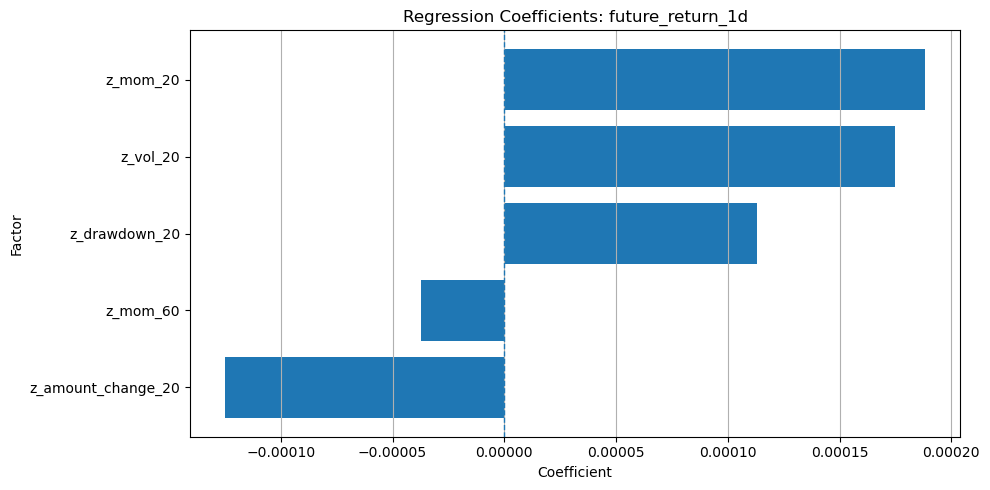

已保存图像: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\figures\regression_coefficients_future_return_1d.png


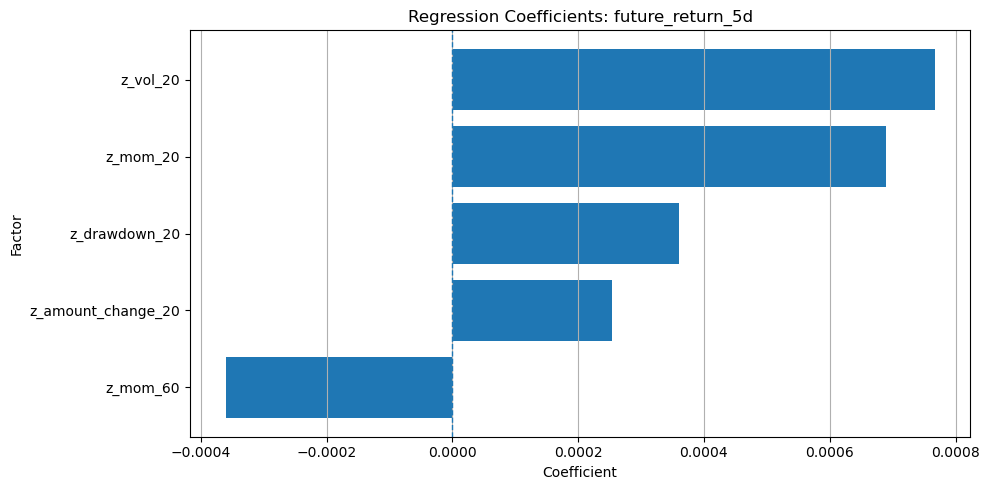

已保存图像: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\figures\regression_coefficients_future_return_5d.png


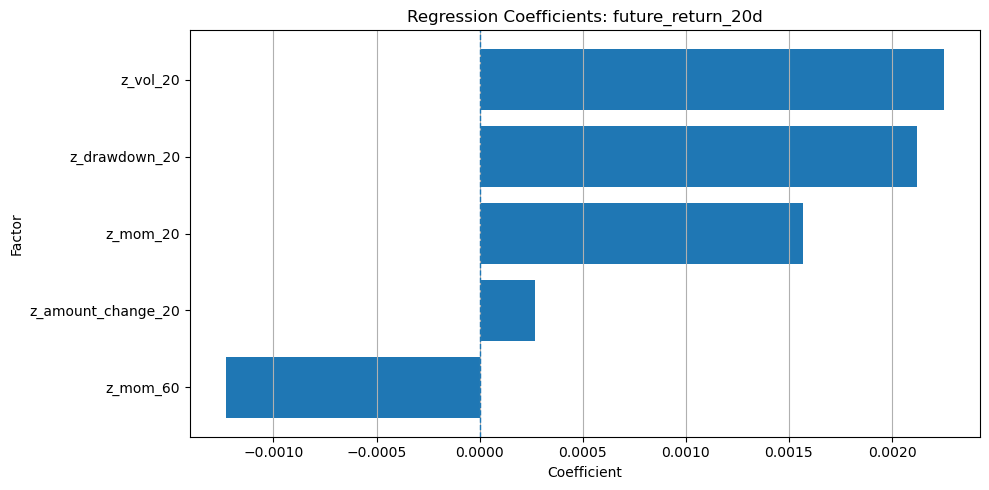

已保存图像: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\figures\regression_coefficients_future_return_20d.png
按日期聚类标准误下，p < 0.1 的变量:


,model_name,y_col,x_var,coef,std_err_cluster_date,t_stat_cluster_date,p_value_cluster_date,std_err_hc3,t_stat_hc3,p_value_hc3,r_squared,adj_r_squared,n_obs
21,future_return_20d_multi_factor,future_return_20d,z_vol_20,0.002252,0.000764,2.948262,0.003196,0.000746,3.018117,0.002544,0.001500,0.001298,24681
22,future_return_20d_multi_factor,future_return_20d,z_drawdown_20,0.002119,0.000779,2.719169,0.006545,0.000861,2.462124,0.013812,0.001500,0.001298,24681
17,future_return_20d_alpha_score_only,future_return_20d,alpha_score,0.001690,0.000752,2.245528,0.024734,0.000690,2.447462,0.014387,0.000298,0.000257,24681
20,future_return_20d_multi_factor,future_return_20d,z_mom_60,-0.001230,0.000728,-1.689516,0.091121,0.000707,-1.738478,0.082127,0.001500,0.001298,24681
19,future_return_20d_multi_factor,future_return_20d,z_mom_20,0.001567,0.000935,1.676086,0.093721,0.000954,1.642121,0.100565,0.001500,0.001298,24681
13,future_return_5d_multi_factor,future_return_5d,z_vol_20,0.000767,0.000375,2.046490,0.040708,0.000361,2.122452,0.033800,0.000703,0.000501,24681


第五部分完成。
输出文件:
C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\regression_coef_table.csv
C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\regression_summary_table.csv
C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\factor_correlation_matrix.csv


,model_name,y_col,x_vars,r_squared,adj_r_squared,n_obs
0,future_return_1d_alpha_score_only,future_return_1d,alpha_score,0.000058,0.000017,24681
1,future_return_1d_multi_factor,future_return_1d,"z_mom_20, z_mom_60, z_vol_20, z_drawdown_20, z...",0.000265,0.000062,24681
2,future_return_5d_alpha_score_only,future_return_5d,alpha_score,0.000112,0.000071,24681
3,future_return_5d_multi_factor,future_return_5d,"z_mom_20, z_mom_60, z_vol_20, z_drawdown_20, z...",0.000703,0.000501,24681
4,future_return_20d_alpha_score_only,future_return_20d,alpha_score,0.000298,0.000257,24681
5,future_return_20d_multi_factor,future_return_20d,"z_mom_20, z_mom_60, z_vol_20, z_drawdown_20, z...",0.001500,0.001298,24681


In [5]:
# 只看多因子模型，不画常数项
plot_coef = regression_coef_table[
    (regression_coef_table["model_name"].str.contains("multi_factor"))
    & (regression_coef_table["x_var"] != "const")
].copy()

# 为了图更清楚，按 horizon 分别画
for y_col in future_return_cols:
    sub = plot_coef[plot_coef["y_col"] == y_col].copy()

    sub = sub.sort_values("coef")

    plt.figure(figsize=(10, 5))
    plt.barh(sub["x_var"], sub["coef"])
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.title(f"Regression Coefficients: {y_col}")
    plt.xlabel("Coefficient")
    plt.ylabel("Factor")
    plt.grid(axis="x")
    plt.tight_layout()

    fig_file = FIGURE_DIR / f"regression_coefficients_{y_col}.png"
    plt.savefig(fig_file, dpi=300)
    plt.show()

    print(f"已保存图像: {fig_file}")

# 输出显著性较强的结果
significant_results = regression_coef_table[
    (regression_coef_table["x_var"] != "const")
    & (regression_coef_table["p_value_cluster_date"] < 0.1)
].copy()

significant_results = significant_results.sort_values(
    ["y_col", "p_value_cluster_date"]
)

print("按日期聚类标准误下，p < 0.1 的变量:")
display(significant_results)

print("第五部分完成。")
print("=" * 60)
print("输出文件:")
print(coef_file)
print(summary_file)
print(corr_file)
print("=" * 60)

regression_summary_table